# Financial Sentiment Classification: BERT vs FinBERT
Multiclass classification: **positive / negative / neutral** sentiment in financial texts.


## 1. Install and import libraries

In [1]:
!pip install transformers datasets scikit-learn torch matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

In [11]:
import os
os.environ["WANDB_DISABLED"] = "true"

## 2. Load dataset from TXT
Format: `text.@label`, where label ∈ {positive, negative, neutral}

In [16]:
file_path = 'Sentences_AllAgree.txt'

label2id = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

texts = []
labels = []

with open(file_path, 'r', encoding='latin1') as f:
    for line in f:
        line = line.strip()
        if line and '.@' in line:
            text, label = line.rsplit('.@', 1)
            label = label.lower()
            if label in label2id:
                texts.append(text)
                labels.append(label2id[label])

df = pd.DataFrame({'text': texts, 'label': labels})

print("Полный датасет:")
print(df['label'].value_counts())

MAX_SAMPLES = 500
NUM_CLASSES = df['label'].nunique()
SAMPLES_PER_CLASS = MAX_SAMPLES // NUM_CLASSES

df_limited = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(
          n=min(len(x), SAMPLES_PER_CLASS),
          random_state=42
      ))
      .reset_index(drop=True)
)

print("\nПосле ограничения:")
print(df_limited['label'].value_counts())
print(f"\nИтого примеров: {len(df_limited)}")

df_limited.head()

df = df_limited


Полный датасет:
label
1    1358
2     557
0     293
Name: count, dtype: int64

После ограничения:
label
0    166
1    166
2    166
Name: count, dtype: int64

Итого примеров: 498


/tmp/ipython-input-3799664321.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


## 3. Train/test split

In [17]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

## 4. Tokenizer and Dataset preparation
Reduced max sequence length for faster training.

In [18]:
model_name_bert = 'bert-base-uncased'
model_name_finbert = 'yiyanghkust/finbert-tone'

tokenizer_bert = AutoTokenizer.from_pretrained(model_name_bert)
tokenizer_finbert = AutoTokenizer.from_pretrained(model_name_finbert)

class FinancialDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset_bert = FinancialDataset(train_texts, train_labels, tokenizer_bert)
test_dataset_bert = FinancialDataset(test_texts, test_labels, tokenizer_bert)

train_dataset_finbert = FinancialDataset(train_texts, train_labels, tokenizer_finbert)
test_dataset_finbert = FinancialDataset(test_texts, test_labels, tokenizer_finbert)

## 5. Metrics (macro-averaged for 3 classes)

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='macro'),
        'recall': recall_score(labels, preds, average='macro'),
        'f1': f1_score(labels, preds, average='macro')
    }

## 6. Fine-tune BERT

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_name_bert,
    num_labels=3
).to(device)

training_args_bert = TrainingArguments(
    output_dir='./checkpoints_bert',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-5,
    fp16=True,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1'
)

trainer_bert = Trainer(
    model=model_bert,
    args=training_args_bert,
    train_dataset=train_dataset_bert,
    eval_dataset=test_dataset_bert,
    tokenizer=tokenizer_bert,
    data_collator=DataCollatorWithPadding(tokenizer_bert),
    compute_metrics=compute_metrics
)

trainer_bert.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-369816272.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_bert = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.959433,0.620000,0.772727,0.625371,0.546713
2,No log,0.858976,0.700000,0.728042,0.699643,0.696542


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=26, training_loss=0.9635408108051007, metrics={'train_runtime': 925.7844, 'train_samples_per_second': 0.86, 'train_steps_per_second': 0.028, 'total_flos': 39269677595904.0, 'train_loss': 0.9635408108051007, 'epoch': 2.0})

## 7. Fine-tune FinBERT

In [21]:
model_finbert = AutoModelForSequenceClassification.from_pretrained(
    model_name_finbert,
    num_labels=3
).to(device)

training_args_finbert = TrainingArguments(
    output_dir='./checkpoints_finbert',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-5,
    fp16=True,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1'
)

trainer_finbert = Trainer(
    model=model_finbert,
    args=training_args_finbert,
    train_dataset=train_dataset_finbert,
    eval_dataset=test_dataset_finbert,
    tokenizer=tokenizer_finbert,
    data_collator=DataCollatorWithPadding(tokenizer_finbert),
    compute_metrics=compute_metrics
)

trainer_finbert.train()

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-3045000944.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_finbert = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.979741,0.600000,0.551143,0.605466,0.527792
2,No log,0.801813,0.610000,0.607550,0.609031,0.574452


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=26, training_loss=1.9642361861008863, metrics={'train_runtime': 962.4919, 'train_samples_per_second': 0.827, 'train_steps_per_second': 0.027, 'total_flos': 39269677595904.0, 'train_loss': 1.9642361861008863, 'epoch': 2.0})

## 8. Evaluation and confusion matrices

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


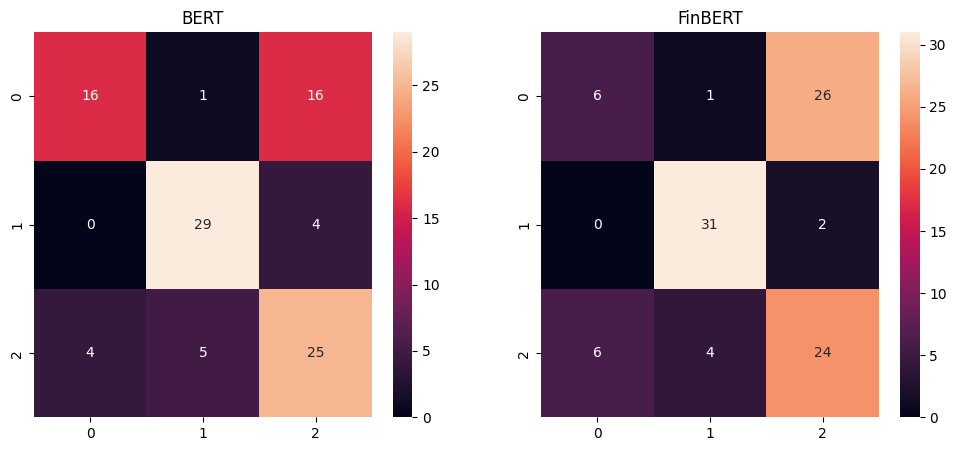

In [22]:
bert_preds = trainer_bert.predict(test_dataset_bert)
finbert_preds = trainer_finbert.predict(test_dataset_finbert)

bert_labels = np.argmax(bert_preds.predictions, axis=1)
finbert_labels = np.argmax(finbert_preds.predictions, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(test_labels, bert_labels), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('BERT')

sns.heatmap(confusion_matrix(test_labels, finbert_labels), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('FinBERT')

plt.show()

## 9. Comparison table

In [23]:
comparison = pd.DataFrame([
    trainer_bert.evaluate(test_dataset_bert),
    trainer_finbert.evaluate(test_dataset_finbert)
], index=['BERT', 'FinBERT'])

comparison

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
BERT,0.858976,0.70,0.728042,0.699643,0.696542,32.6916,3.059,0.122,2.0
FinBERT,0.801813,0.61,0.607550,0.609031,0.574452,29.9851,3.335,0.133,2.0


## 10. Discussion
BERT показала accuracy 70%, precision 72.8%, recall 70.0%, F1-score 69.7%.
FinBERT показала accuracy 61%, precision 60.8%, recall 60.9%, F1-score 57.4%.

Модель BERT превзошла FinBERT по всем основным метрикам классификации.